# Octree Leaf (L0) — Architecture Shootout

This notebook tests candidate architectures for **Model C (`octree_leaf`)**, the
leaf-level model that generates final block-level 32³ sections from parent context.

## Candidates

| ID | Architecture | Channels | Parent Strategy | Rationale |
|----|-------------|----------|----------------|-----------||
| C1 | Full 3D U-Net | [48,96,192] | Concat input | Baseline — same as refine without occ head |
| C2 | Full 3D U-Net (deeper bottleneck) | [48,96,192] | Concat input | Extra bottleneck capacity for fine detail |
| C3 | Residual U-Net | [48,96,192] | Concat + residual skip | ResNet-style encoder for gradient flow |
| C4 | U-Net with attention at 8³ | [48,96,192] | Concat input | Attention for global block coherence |

## Metrics
- Block accuracy (overall, air, non-air)
- Top-5 accuracy
- Inference latency (CPU)
- Parameter count
- **No occupancy metrics** — L0 has no children

In [4]:
from __future__ import annotations

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import octree_shootout_utils as shootout_utils

importlib.reload(shootout_utils)

from octree_shootout_utils import (
    ARTIFACT_DIR,
    DATA_DIR,
    DEVICE,
    NUM_BIOMES,
    NUM_BLOCK_CLASSES,
    NUM_Y_POSITIONS,
    ROOT,
    SEED,
    SPATIAL,
    benchmark_latency as shared_benchmark_latency,
    compute_block_log_priors,
    compute_block_metrics,
    cross_entropy_loss,
    describe_split,
    init_block_head_bias,
    load_pair_cache_subset,
    make_loader,
    maybe_corrupt_parent,
    maybe_load_class_weights,
    seed_everything,
)

seed_everything(SEED)
CLASS_WEIGHTS = maybe_load_class_weights(DATA_DIR)

print("ROOT =", ROOT)
print("DATA_DIR =", DATA_DIR)
print("DEVICE =", DEVICE)
print("CLASS_WEIGHTS =", None if CLASS_WEIGHTS is None else tuple(CLASS_WEIGHTS.shape))

ROOT = c:\Users\JeffHall\git\MC\VoxelTree
DATA_DIR = c:\Users\JeffHall\git\MC\VoxelTree\data\voxy_octree
DEVICE = cpu
CLASS_WEIGHTS = None


## Data Loading

Load real L0 training data from the production pair caches. Each sample includes:
- `labels32`: target 32³ block IDs (1m/voxel — final block resolution)
- `parent_labels32`: parent block IDs (extracted octant from L1, upsampled 2× to 32³)
- `heightmap32`: 5-channel height features (surface, ocean_floor, slope_x, slope_z, curvature)
- `biome32`: biome indices per `(x, z)` column
- `y_position`: integer Y section coordinate `(0–23)`

L0 is the highest-fidelity level and has **no `non_empty_children`** target.

If the pair caches are missing, the notebook now fails immediately instead of falling back to synthetic data.

In [5]:
AIR = 0
STONE = 1
DIRT = 3
GRASS_BLOCK = 9
SAND = 66
WATER = 34
DEEPSLATE = 899

# Quick-shootout controls (set to None for full split)
TRAIN_MAX_SAMPLES = 2048
VAL_MAX_SAMPLES = None


def load_leaf_data() -> tuple[dict, dict]:
    train_data = load_pair_cache_subset("train", levels=[0], include_parent=True)
    val_data = load_pair_cache_subset("val", levels=[0], include_parent=True)
    if train_data is None or val_data is None:
        raise FileNotFoundError(
            "Missing required pair caches for leaf shootout. Expected "
            "data/voxy_octree/train_octree_pairs.npz and val_octree_pairs.npz."
        )
    print("Loaded production pair caches for L0 leaf shootout.")
    return train_data, val_data


def subsample_leaf_data(data: dict, max_samples: int | None, seed: int = SEED) -> dict:
    labels = data["labels32"]
    total = int(labels.shape[0])
    if max_samples is None or max_samples >= total:
        return data

    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(total, size=max_samples, replace=False))

    subset = {}
    for key, value in data.items():
        if isinstance(value, np.ndarray) and value.shape[0] == total:
            subset[key] = value[idx]
        else:
            subset[key] = value
    return subset


train_data, val_data = load_leaf_data()
train_data = subsample_leaf_data(train_data, TRAIN_MAX_SAMPLES, seed=SEED)
val_data = subsample_leaf_data(val_data, VAL_MAX_SAMPLES, seed=SEED + 1)

BLOCK_LOG_PRIORS = compute_block_log_priors(
    train_data["labels32"],
    num_classes=NUM_BLOCK_CLASSES,
)

print(
    f"Using L0 samples — train: {train_data['labels32'].shape[0]:,} "
    f"(cap={TRAIN_MAX_SAMPLES}), val: {val_data['labels32'].shape[0]:,} "
    f"(cap={VAL_MAX_SAMPLES})"
)

describe_split("train", train_data)
describe_split("val", val_data)

Loaded production pair caches for L0 leaf shootout.
Computed block priors: total_voxels=67,108,864 air=23.45% seen=199/1104
Using L0 samples — train: 2,048 (cap=2048), val: 1,226 (cap=None)
train:
  labels32: shape=(2048, 32, 32, 32) dtype=int32
  heightmap32: shape=(2048, 5, 32, 32) dtype=float32
  biome32: shape=(2048, 32, 32) dtype=int32
  y_position: shape=(2048,) dtype=int64
  parent_labels32: shape=(2048, 32, 32, 32) dtype=int32
val:
  labels32: shape=(1226, 32, 32, 32) dtype=int32
  heightmap32: shape=(1226, 5, 32, 32) dtype=float32
  biome32: shape=(1226, 32, 32) dtype=int32
  y_position: shape=(1226,) dtype=int64
  parent_labels32: shape=(1226, 32, 32, 32) dtype=int32


In [6]:
BATCH_SIZE = 8
train_loader = make_loader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    include_parent=True,
)
val_loader = make_loader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    include_parent=True,
)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"{k}: {tuple(v.shape)} {v.dtype}")

labels32: (8, 32, 32, 32) torch.int64
heightmap32: (8, 5, 32, 32) torch.float32
biome32: (8, 32, 32) torch.int64
y_position: (8,) torch.int64
parent_labels32: (8, 32, 32, 32) torch.int64


## Building Blocks

Shared components for all leaf model candidates.

In [7]:
class Conv3dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DoubleConv3d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(Conv3dBlock(in_ch, out_ch), Conv3dBlock(out_ch, out_ch))

    def forward(self, x):
        return self.block(x)


class ParentEncoder(nn.Module):
    """Embed parent block IDs into a dense 3D feature volume."""

    def __init__(self, out_ch: int, embed_dim: int = 16):
        super().__init__()
        self.block_emb = nn.Embedding(NUM_BLOCK_CLASSES, embed_dim)
        self.conv = nn.Sequential(
            nn.Conv3d(embed_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, parent_labels: torch.Tensor) -> torch.Tensor:
        emb = self.block_emb(parent_labels.clamp(0, NUM_BLOCK_CLASSES - 1))
        emb = emb.permute(0, 4, 1, 2, 3)
        return self.conv(emb)


class ConditioningEncoder2D(nn.Module):
    """Encode heightmap + biome -> 2D features -> expand to 3D volume."""

    def __init__(self, out_ch: int, biome_dim: int = 8, y_dim: int = 8):
        super().__init__()
        self.biome_emb = nn.Embedding(NUM_BIOMES, biome_dim)
        self.y_emb = nn.Embedding(NUM_Y_POSITIONS, y_dim)
        self.conv2d = nn.Sequential(
            nn.Conv2d(5 + biome_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.y_proj = nn.Linear(y_dim, out_ch)

    def forward(self, hm, biome, y_pos):
        B = hm.shape[0]
        biome_feat = self.biome_emb(biome.clamp(0, NUM_BIOMES - 1)).permute(0, 3, 1, 2)
        cond_2d = self.conv2d(torch.cat([hm, biome_feat], dim=1))
        cond_3d = cond_2d.unsqueeze(2).expand(-1, -1, SPATIAL, -1, -1)
        y_feat = self.y_proj(self.y_emb(y_pos.clamp(0, NUM_Y_POSITIONS - 1))).view(B, -1, 1, 1, 1)
        return cond_3d + y_feat


print("Building blocks defined.")

Building blocks defined.


## Candidate C1: Full 3D U-Net (`concat_leaf`)

Standard 3D U-Net with parent features concatenated as input channels.
Same strategy as refine B1 but **no occupancy head** — L0 has no children.

- ConditioningEncoder2D → c0//2 channels
- ParentEncoder → c0//2 channels
- Concat → c0 channels → 3D U-Net encoder/decoder
- block_head: Conv3d(c0, NUM_BLOCK_CLASSES, 1)

In [8]:
class ConcatLeafUNet(nn.Module):
    """Full 3D U-Net with parent context concatenated as input channels.

    No occupancy head -- L0 is the leaf level with no children.
    Default channels: [48, 96, 192] (~1.8M params).
    """

    def __init__(
        self,
        c0: int = 48,
        c1: int = 96,
        c2: int = 192,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)

        # Encoder
        self.enc1 = DoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {"block_logits": self.block_head(d1)}


_m = ConcatLeafUNet(c0=48, c1=96, c2=192)
with torch.no_grad():
    _out = _m(batch)
print("C1 ConcatLeafUNet [48,96,192]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

C1 ConcatLeafUNet [48,96,192]: {'block_logits': (8, 1104, 32, 32, 32)}
  Params: 3,324,224


## Candidate C2: Deeper Bottleneck (`deeper_bn_leaf`)

Same as C1 but with an **extra DoubleConv3d at the 8³ bottleneck** for more
capacity at the lowest spatial resolution. This gives the network more
expressiveness where it can reason about global structure cheaply.

In [9]:
class DeeperBottleneckLeafUNet(nn.Module):
    """Full 3D U-Net with extra bottleneck conv block at 8^3.

    Identical to C1 except for an additional DoubleConv3d(c2, c2) at
    the bottleneck before decoding begins.
    """

    def __init__(
        self,
        c0: int = 48,
        c1: int = 96,
        c2: int = 192,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)

        # Encoder
        self.enc1 = DoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Extra bottleneck capacity
        self.extra_bottleneck = DoubleConv3d(c2, c2)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))
        bn = self.extra_bottleneck(bn)

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {"block_logits": self.block_head(d1)}


_m = DeeperBottleneckLeafUNet(c0=48, c1=96, c2=192)
with torch.no_grad():
    _out = _m(batch)
print("C2 DeeperBottleneckLeafUNet [48,96,192]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

C2 DeeperBottleneckLeafUNet [48,96,192]: {'block_logits': (8, 1104, 32, 32, 32)}
  Params: 5,315,648


## Candidate C3: Residual U-Net (`residual_leaf`)

Replaces encoder DoubleConv3d blocks with **residual versions** for better
gradient flow. Each ResDoubleConv3d block adds a 1×1 skip connection around
the two-conv block, similar to ResNet basic blocks.

In [10]:
class ResDoubleConv3d(nn.Module):
    """DoubleConv3d with a residual (skip) connection.

    Uses a 1x1 conv to match channel dimensions when in_ch != out_ch,
    otherwise an identity skip.
    """

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(Conv3dBlock(in_ch, out_ch), Conv3dBlock(out_ch, out_ch))
        self.skip = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)


class ResidualLeafUNet(nn.Module):
    """3D U-Net with ResNet-style skip connections in the encoder.

    Encoder uses ResDoubleConv3d for better gradient flow.
    Decoder uses standard DoubleConv3d (residual not needed
    since skip connections already provide alternative paths).
    """

    def __init__(
        self,
        c0: int = 48,
        c1: int = 96,
        c2: int = 192,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)

        # Residual encoder
        self.enc1 = ResDoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ResDoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = ResDoubleConv3d(c1, c2)

        # Decoder (standard)
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {"block_logits": self.block_head(d1)}


_m = ResidualLeafUNet(c0=48, c1=96, c2=192)
with torch.no_grad():
    _out = _m(batch)
print("C3 ResidualLeafUNet [48,96,192]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

C3 ResidualLeafUNet [48,96,192]: {'block_logits': (8, 1104, 32, 32, 32)}
  Params: 3,347,552


## Candidate C4: U-Net with Self-Attention at 8³ (`attention_leaf`)

Standard 3D U-Net with **multi-head self-attention (4 heads)** applied at
the 8³ bottleneck spatial resolution. Self-attention at this scale is
tractable (512 tokens) and lets the model capture global block coherence
patterns that purely convolutional models may miss.

In [11]:
class SelfAttention3d(nn.Module):
    """Multi-head self-attention for 3D feature maps at bottleneck resolution."""

    def __init__(self, ch: int, heads: int = 4):
        super().__init__()
        self.mha = nn.MultiheadAttention(ch, heads, batch_first=True)
        self.norm = nn.LayerNorm(ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, D, H, W = x.shape
        flat = x.reshape(B, C, -1).permute(0, 2, 1)  # B, D*H*W, C
        out = self.mha(flat, flat, flat)[0]
        out = self.norm(out + flat)
        return out.permute(0, 2, 1).reshape(B, C, D, H, W)


class AttentionLeafUNet(nn.Module):
    """3D U-Net with self-attention at the 8^3 bottleneck.

    After the bottleneck encoder, self-attention is applied to let
    the model reason about global spatial relationships between
    all 512 bottleneck positions before decoding.
    """

    def __init__(
        self,
        c0: int = 48,
        c1: int = 96,
        c2: int = 192,
        num_classes: int = NUM_BLOCK_CLASSES,
        parent_dim: int = 16,
    ):
        super().__init__()
        self.cond = ConditioningEncoder2D(out_ch=c0 // 2)
        self.parent_enc = ParentEncoder(out_ch=c0 // 2, embed_dim=parent_dim)

        # Encoder
        self.enc1 = DoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Self-attention at 8^3 bottleneck
        self.attn = SelfAttention3d(c2, heads=4)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)

    def forward(self, batch: dict) -> dict:
        cond = self.cond(batch["heightmap32"], batch["biome32"], batch["y_position"])
        parent_feat = self.parent_enc(batch["parent_labels32"])
        x = torch.cat([cond, parent_feat], dim=1)

        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))
        bn = self.attn(bn)

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return {"block_logits": self.block_head(d1)}


_m = AttentionLeafUNet(c0=48, c1=96, c2=192)
with torch.no_grad():
    _out = _m(batch)
print("C4 AttentionLeafUNet [48,96,192]:", {k: tuple(v.shape) for k, v in _out.items()})
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

C4 AttentionLeafUNet [48,96,192]: {'block_logits': (8, 1104, 32, 32, 32)}
  Params: 3,472,832


## Training Loop

**Loss:** weighted cross-entropy on `block_logits` only.

**Real-data alignment:** uses production pair caches, production `class_weights.npz` when available, and light parent corruption during training to mimic rollout noise from the refine model.

In [12]:
PARENT_CORRUPTION_P = 0.15


def compute_loss(model_out: dict, batch: dict) -> tuple[torch.Tensor, dict]:
    block_logits = model_out["block_logits"]
    class_weights = CLASS_WEIGHTS.to(block_logits.device) if CLASS_WEIGHTS is not None else None
    block_loss = cross_entropy_loss(block_logits, batch["labels32"], class_weights=class_weights)
    return block_loss, {"block_loss": block_loss.item(), "total_loss": block_loss.item()}


@torch.no_grad()
def evaluate(model: nn.Module, loader) -> dict:
    model.eval()
    total_loss_sum = 0.0
    total_samples = 0
    accum = {
        "block_acc": 0.0,
        "air_acc": 0.0,
        "nonair_acc": 0.0,
        "top5_acc": 0.0,
    }

    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(batch)
        loss, _ = compute_loss(out, batch)
        bsz = batch["labels32"].shape[0]
        total_loss_sum += loss.item() * bsz
        total_samples += bsz

        block_metrics = compute_block_metrics(
            out["block_logits"], batch["labels32"], air_id=AIR, topk=5
        )
        for key, value in block_metrics.items():
            accum[key] += value * bsz

    return {
        "val_loss": total_loss_sum / max(total_samples, 1),
        "block_acc": accum["block_acc"] / max(total_samples, 1),
        "air_acc": accum["air_acc"] / max(total_samples, 1),
        "nonair_acc": accum["nonair_acc"] / max(total_samples, 1),
        "top5_acc": accum["top5_acc"] / max(total_samples, 1),
    }


def train_and_evaluate(
    model: nn.Module, name: str, train_loader, val_loader, epochs: int = 15, lr: float = 3e-4
):
    model = model.to(DEVICE)
    init_block_head_bias(model, BLOCK_LOG_PRIORS, model_name=name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            batch["parent_labels32"] = maybe_corrupt_parent(
                batch["parent_labels32"],
                probability=PARENT_CORRUPTION_P,
                vocab_size=NUM_BLOCK_CLASSES,
            )
            optimizer.zero_grad(set_to_none=True)
            loss, _ = compute_loss(model(batch), batch)
            loss.backward()
            optimizer.step()
            running += loss.item() * batch["labels32"].shape[0]
            seen += batch["labels32"].shape[0]
        scheduler.step()

        val_metrics = evaluate(model, val_loader)
        row = {"model": name, "epoch": epoch, "train_loss": running / max(seen, 1), **val_metrics}
        rows.append(row)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  [{name}] ep {epoch:2d}  loss={row['train_loss']:.4f}  "
                f"block_acc={row['block_acc']:.4f}  nonair_acc={row['nonair_acc']:.4f}  "
                f"top5={row['top5_acc']:.4f}"
            )

    model_cpu = model.cpu().eval()
    latency = shared_benchmark_latency(
        model_cpu, next(iter(val_loader)), device="cpu", warmup=5, steps=20
    )
    best_row = min(rows, key=lambda r: r["val_loss"])
    n_params = sum(p.numel() for p in model_cpu.parameters())

    return {
        "model_obj": model_cpu,
        "history": pd.DataFrame(rows),
        "best_epoch": best_row["epoch"],
        "block_acc": best_row["block_acc"],
        "air_acc": best_row["air_acc"],
        "nonair_acc": best_row["nonair_acc"],
        "top5_acc": best_row["top5_acc"],
        "val_loss": best_row["val_loss"],
        "params": n_params,
        "ms_per_sample": latency["ms_per_sample"],
    }


print("Training infrastructure ready.")

Training infrastructure ready.


## Run Shootout

4 candidates: C1 (concat), C2 (deeper bottleneck), C3 (residual), C4 (attention).

Quick mode defaults:
- train cap: `TRAIN_MAX_SAMPLES = 2048`
- validation cap: `VAL_MAX_SAMPLES = None` (full val split)
- epochs: `EPOCHS = 2`

In [13]:
EPOCHS = 2

candidates = {
    "C1_concat": ConcatLeafUNet(c0=48, c1=96, c2=192),
    "C2_deeper_bn": DeeperBottleneckLeafUNet(c0=48, c1=96, c2=192),
    "C3_residual": ResidualLeafUNet(c0=48, c1=96, c2=192),
    "C4_attention": AttentionLeafUNet(c0=48, c1=96, c2=192),
}

print(f"Quick leaf shootout: {len(candidates)} candidates, {EPOCHS} epochs each")

results = {}
for name, model in candidates.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f'\n{"=" * 60}\n{name}: {n_params:,} params\n{"=" * 60}')
    results[name] = train_and_evaluate(model, name, train_loader, val_loader, epochs=EPOCHS)

Quick leaf shootout: 4 candidates, 2 epochs each

C1_concat: 3,324,224 params
  ✓ Initialized C1_concat.block_head bias from log-frequency priors
  [C1_concat] ep  1  loss=1.3875  block_acc=0.7318  nonair_acc=0.7066  top5=0.9120

C2_deeper_bn: 5,315,648 params
  ✓ Initialized C2_deeper_bn.block_head bias from log-frequency priors
  [C2_deeper_bn] ep  1  loss=1.4087  block_acc=0.7317  nonair_acc=0.7099  top5=0.9167

C3_residual: 3,347,552 params
  ✓ Initialized C3_residual.block_head bias from log-frequency priors
  [C3_residual] ep  1  loss=1.3660  block_acc=0.7421  nonair_acc=0.7210  top5=0.9182

C4_attention: 3,472,832 params
  ✓ Initialized C4_attention.block_head bias from log-frequency priors
  [C4_attention] ep  1  loss=1.3968  block_acc=0.7136  nonair_acc=0.6869  top5=0.9062


## Results Comparison

In [14]:
# -- Summary table ---------------------------------------------------
summary_rows = []
for name, res in results.items():
    summary_rows.append(
        {
            "model": name,
            "params": res["params"],
            "best_epoch": res["best_epoch"],
            "block_acc": res["block_acc"],
            "air_acc": res["air_acc"],
            "nonair_acc": res["nonair_acc"],
            "top5_acc": res["top5_acc"],
            "val_loss": res["val_loss"],
            "ms_per_sample": res["ms_per_sample"],
        }
    )

summary_df = (
    pd.DataFrame(summary_rows).sort_values("block_acc", ascending=False).reset_index(drop=True)
)
print(summary_df.to_string(index=False))
summary_df

       model  params  best_epoch  block_acc  air_acc  nonair_acc  top5_acc  val_loss  ms_per_sample
C2_deeper_bn 5315648           2   0.753053 0.785774    0.724901  0.928767  1.007812      91.283629
 C3_residual 3347552           2   0.752197 0.800155    0.719673  0.928678  1.014771      89.676869
   C1_concat 3324224           2   0.747601 0.747640    0.727527  0.924766  1.030102      90.833577
C4_attention 3472832           2   0.742214 0.773031    0.714447  0.921024  1.047587      88.591156


,model,params,best_epoch,block_acc,air_acc,nonair_acc,top5_acc,val_loss,ms_per_sample
0,C2_deeper_bn,5315648,2,0.753053,0.785774,0.724901,0.928767,1.007812,91.283629
1,C3_residual,3347552,2,0.752197,0.800155,0.719673,0.928678,1.014771,89.676869
2,C1_concat,3324224,2,0.747601,0.747640,0.727527,0.924766,1.030102,90.833577
3,C4_attention,3472832,2,0.742214,0.773031,0.714447,0.921024,1.047587,88.591156


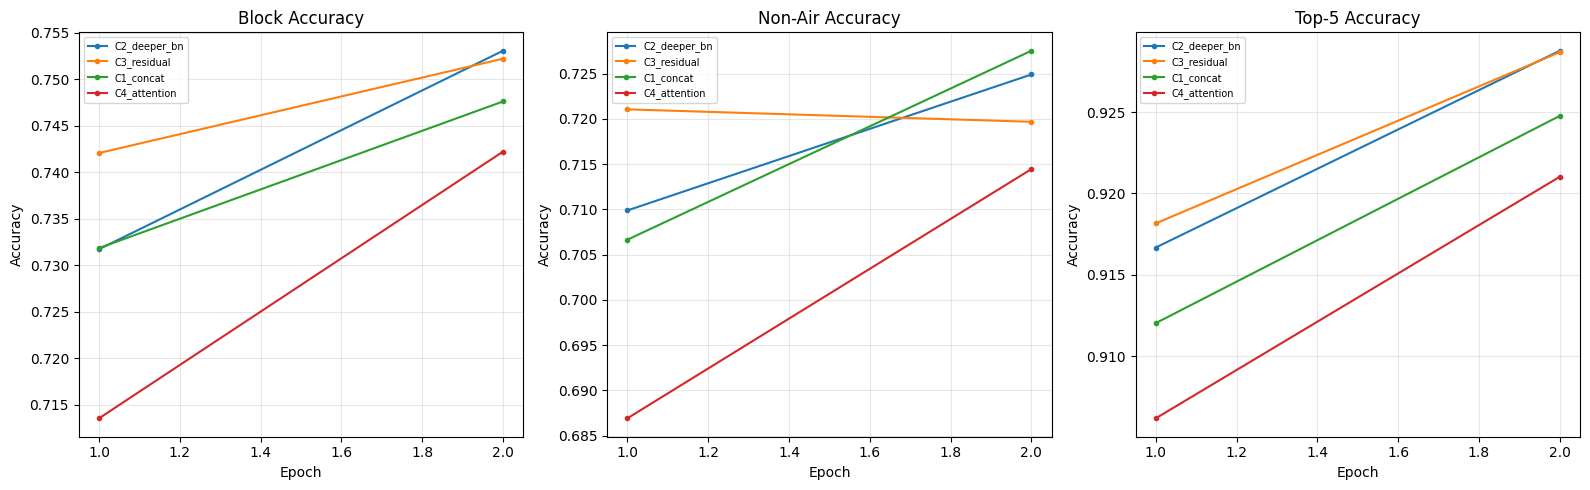

In [15]:
# -- Learning curves -------------------------------------------------
history_df = pd.concat([r["history"] for r in results.values()], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for name in summary_df["model"].tolist():
    sub = history_df[history_df["model"] == name]
    axes[0].plot(sub["epoch"], sub["block_acc"], label=name, marker="o", ms=3)
    axes[1].plot(sub["epoch"], sub["nonair_acc"], label=name, marker="o", ms=3)
    axes[2].plot(sub["epoch"], sub["top5_acc"], label=name, marker="o", ms=3)

for i, title in enumerate(["Block Accuracy", "Non-Air Accuracy", "Top-5 Accuracy"]):
    axes[i].set(title=title, xlabel="Epoch", ylabel="Accuracy")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

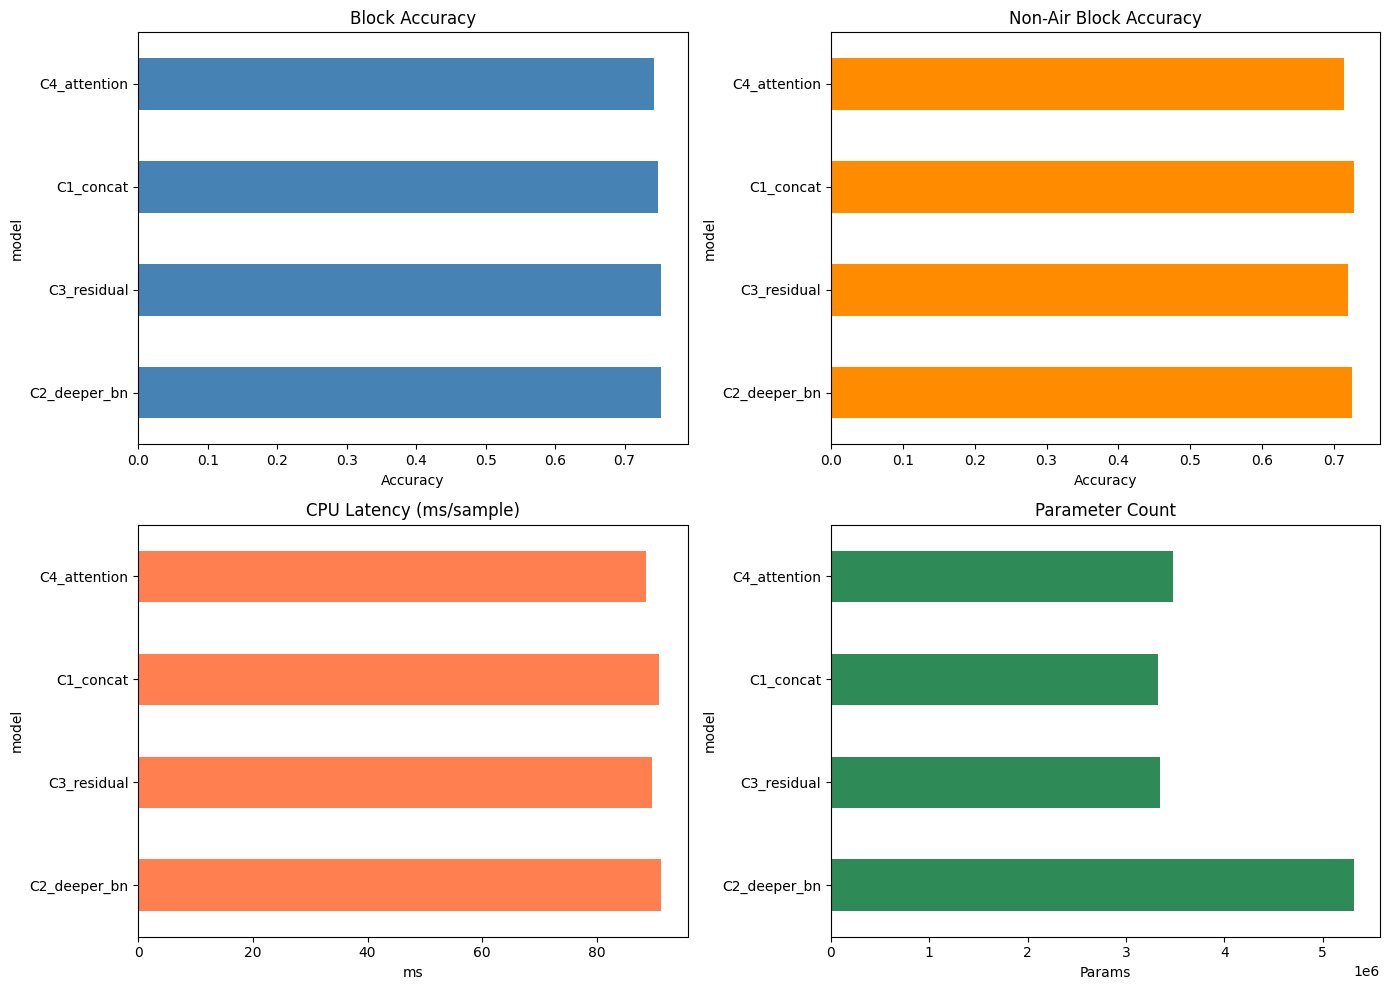

In [16]:
# -- Bar chart comparison --------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

summary_df.plot.barh(y="block_acc", x="model", ax=axes[0, 0], legend=False, color="steelblue")
axes[0, 0].set(title="Block Accuracy", xlabel="Accuracy")

summary_df.plot.barh(y="nonair_acc", x="model", ax=axes[0, 1], legend=False, color="darkorange")
axes[0, 1].set(title="Non-Air Block Accuracy", xlabel="Accuracy")

summary_df.plot.barh(y="ms_per_sample", x="model", ax=axes[1, 0], legend=False, color="coral")
axes[1, 0].set(title="CPU Latency (ms/sample)", xlabel="ms")

summary_df.plot.barh(y="params", x="model", ax=axes[1, 1], legend=False, color="seagreen")
axes[1, 1].set(title="Parameter Count", xlabel="Params")

plt.tight_layout()
plt.show()

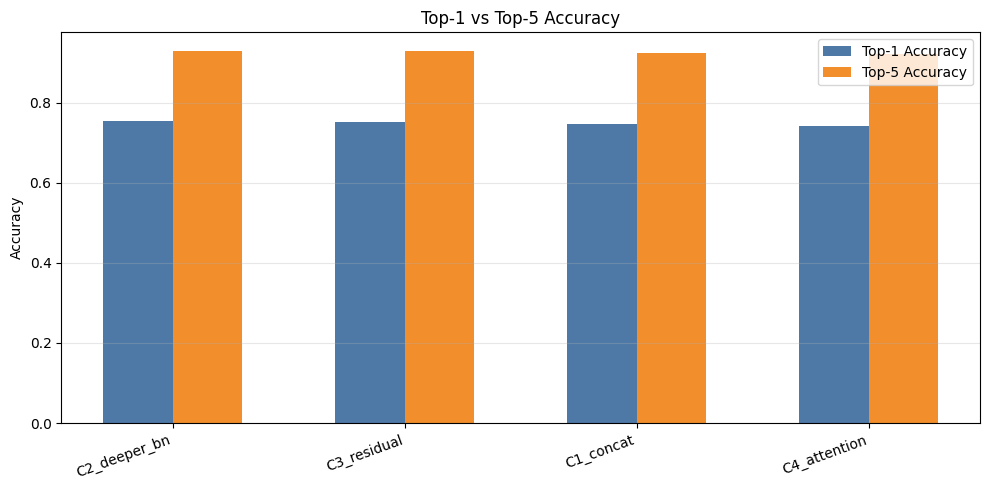

Results saved to c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\leaf_shootout_results.csv
History saved to c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\leaf_shootout_history.csv


In [17]:
# -- Top-5 accuracy grouped bar + save CSV ---------------------------
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_df))
w = 0.3
ax.bar(x - w / 2, summary_df["block_acc"], w, label="Top-1 Accuracy", color="#4e79a7")
ax.bar(x + w / 2, summary_df["top5_acc"], w, label="Top-5 Accuracy", color="#f28e2b")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["model"], rotation=20, ha="right")
ax.set(title="Top-1 vs Top-5 Accuracy", ylabel="Accuracy")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Save results
csv_path = ARTIFACT_DIR / "leaf_shootout_results.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}")

hist_path = ARTIFACT_DIR / "leaf_shootout_history.csv"
history_df.to_csv(hist_path, index=False)
print(f"History saved to {hist_path}")

## Channel Width Sweep

Test the winning architecture (C1 as default) with different channel widths
to find the best capacity-latency tradeoff for production deployment.

In [18]:
# Use the C1 architecture for the channel sweep (simplest baseline).
# Replace with the actual winner class if different.
SweepClass = ConcatLeafUNet

channel_configs = {
    "narrow_32_64_128": (32, 64, 128),
    "default_48_96_192": (48, 96, 192),
    "wide_64_128_256": (64, 128, 256),
}

sweep_results = {}
for cfg_name, (c0, c1, c2) in channel_configs.items():
    model = SweepClass(c0=c0, c1=c1, c2=c2)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'\n{"=" * 60}\n{cfg_name}: {n_params:,} params\n{"=" * 60}')
    sweep_results[cfg_name] = train_and_evaluate(
        model, cfg_name, train_loader, val_loader, epochs=EPOCHS
    )


narrow_32_64_128: 1,504,304 params
  ✓ Initialized narrow_32_64_128.block_head bias from log-frequency priors
  [narrow_32_64_128] ep  1  loss=1.4751  block_acc=0.7208  nonair_acc=0.6959  top5=0.8982

default_48_96_192: 3,324,224 params
  ✓ Initialized default_48_96_192.block_head bias from log-frequency priors
  [default_48_96_192] ep  1  loss=1.3945  block_acc=0.7096  nonair_acc=0.6725  top5=0.9187

wide_64_128_256: 5,862,992 params
  ✓ Initialized wide_64_128_256.block_head bias from log-frequency priors
  [wide_64_128_256] ep  1  loss=1.3573  block_acc=0.7369  nonair_acc=0.7040  top5=0.9199


## Channel Width Results

           config  params  block_acc  air_acc  nonair_acc  top5_acc  val_loss  ms_per_sample
  wide_64_128_256 5862992   0.753661 0.752546    0.738042  0.933188  0.975521     125.285850
default_48_96_192 3324224   0.751225 0.780594    0.724106  0.933324  1.008399      87.371112
 narrow_32_64_128 1504304   0.739861 0.758888    0.715009  0.918884  1.108120      44.938532


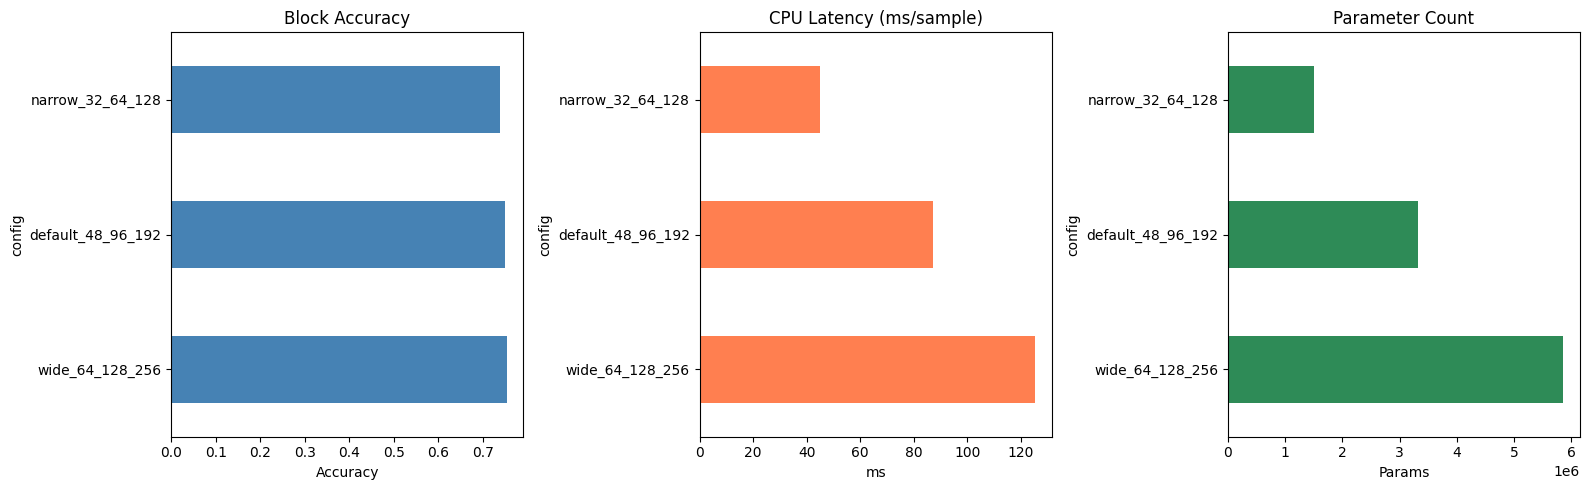

Channel sweep results saved to c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\leaf_channel_sweep_results.csv


In [19]:
sweep_rows = []
for name, res in sweep_results.items():
    sweep_rows.append(
        {
            "config": name,
            "params": res["params"],
            "block_acc": res["block_acc"],
            "air_acc": res["air_acc"],
            "nonair_acc": res["nonair_acc"],
            "top5_acc": res["top5_acc"],
            "val_loss": res["val_loss"],
            "ms_per_sample": res["ms_per_sample"],
        }
    )

sweep_df = pd.DataFrame(sweep_rows).sort_values("block_acc", ascending=False).reset_index(drop=True)
print(sweep_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sweep_df.plot.barh(y="block_acc", x="config", ax=axes[0], legend=False, color="steelblue")
axes[0].set(title="Block Accuracy", xlabel="Accuracy")

sweep_df.plot.barh(y="ms_per_sample", x="config", ax=axes[1], legend=False, color="coral")
axes[1].set(title="CPU Latency (ms/sample)", xlabel="ms")

sweep_df.plot.barh(y="params", x="config", ax=axes[2], legend=False, color="seagreen")
axes[2].set(title="Parameter Count", xlabel="Params")

plt.tight_layout()
plt.show()

sweep_csv = ARTIFACT_DIR / "leaf_channel_sweep_results.csv"
sweep_df.to_csv(sweep_csv, index=False)
print(f"Channel sweep results saved to {sweep_csv}")

## Summary & Recommendations

### Key Questions Answered

1. **Does a deeper bottleneck help at L0?** C2 adds an extra conv block at 8³ — does
   the additional capacity improve fine-detail generation?
2. **Do residual connections help?** C3 uses ResNet-style skips in the encoder — does
   improved gradient flow matter for this model size?
3. **Is self-attention worth the cost?** C4 applies self-attention at 8³ (512 tokens) —
   does global coherence improve block accuracy enough to justify the latency?
4. **What channel widths balance accuracy and latency?** The sweep tests narrow (32/64/128),
   default (48/96/192), and wide (64/128/256) configurations.

### Decision Criteria (ordered priority)

1. **Non-air block accuracy** — the hardest metric at L0 (air is easy to predict)
2. **Top-5 accuracy** — important for sampling-based generation
3. **Overall block accuracy** ≥ 1pp gap → winner
4. Tie: fewer params → winner
5. Tie: lower latency → winner

### Key Differences from Refine (Model B)

- **No occupancy head** — L0 is the leaf level, no children to predict
- **No level embedding** — L0 operates at a single level only
- **Higher channel widths** — [48,96,192] default vs [32,64,128] for refine
- **Focused on block detail** — this model must produce the final, highest-fidelity output

### Next Steps
- Integrate the winning architecture into the production `OctreeLeafModel`
- Test on real Voxy data with actual L1 parent predictions
- Verify the channel width choice on real data (synthetic may not capture full complexity)
- Export to ONNX for Java integration testing

In [20]:
print("Leaf shootout complete. Results saved to:", ARTIFACT_DIR)

Leaf shootout complete. Results saved to: c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts
